# BigSMILES → IR → Monomer/Atomistic → RDKit 可视化
本笔记演示：
1. 使用内置解析器将给定字符串解析为 IR
2. 转换为 Monomer 模板和模拟序列，以及 Atomistic 结构
3. 转换为 RDKit Chem.Mol 并进行绘图（分别绘制 Monomer 集合与最终 Polymer（基于当前 Atomistic 输出））

In [ ]:
from molpy.parser.smiles import parse
from molpy.parser.convert import ir_to_bigsmiles, ir_to_atomistic, ir_to_gbigsmiles
from molpy.adapter.rdkit import monomer_to_rdkit, atomistic_to_rdkit
from molpy.core.aa import Atom as AAAtom

from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage, MolToImage
from IPython.display import display

# 目标字符串（包含 BigSMILES 与分布信息）
s = 'CCOC(=O)C(C)(C){[>][<|8|]CC([>|8|])c1ccccc1, [<|2|]CC([>|2|])C(=O)OC [<]}|schulz_zimm(1500, 1400)|[Br].|5e5|'

doc = parse(s)
print('Features:', doc.features)

# 生成 Monomer 模板；由于定义了 Schulz-Zimm 分布，这里不生成 mock 序列（sequence_length=None）
result = ir_to_gbigsmiles(doc, seed=42)
# monomers = result.monomers
# sequence = result.sequence
# print('Monomer keys:', list(monomers.keys()))
# print('Sequence: ->', sequence)

# # 将 monomer 转为 RDKit 分子并绘制
# mono_mols = []
# mono_titles = []
# for k, m in monomers.items():
#     try:
#         mol = monomer_to_rdkit(m)
#         mono_mols.append(mol)
#         mono_titles.append(k)
#     except Exception as e:
#         print(f'RDKit conversion failed for monomer {k}:', e)

# if mono_mols:
#     img = MolsToGridImage(mono_mols, molsPerRow=3, subImgSize=(250, 200), legends=mono_titles)
#     display(img)
# else:
#     print('No monomer molecules to display')

# # 转为 Atomistic（注意：当前实现对 BigSMILES 重复单元不进行聚合，仅转换确定性部分）
# atomistic = ir_to_atomistic(doc)
# print('Atomistic atoms:', len(list(atomistic.atoms)))
# # 将 Atomistic 转为 RDKit 并绘图
# try:
#     poly_mol = atomistic_to_rdkit(atomistic)
#     display(MolToImage(poly_mol, size=(300, 250)))
# except Exception as e:
#     print('RDKit conversion failed for polymer (atomistic):', e)

Features: {'bigsmiles', 'smiles', 'gbigsmiles'}


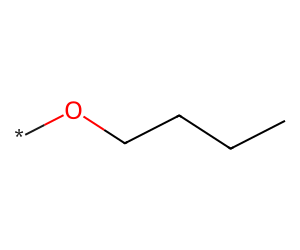

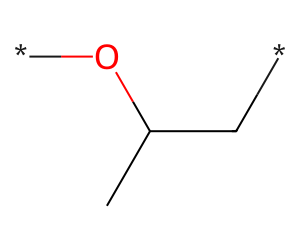

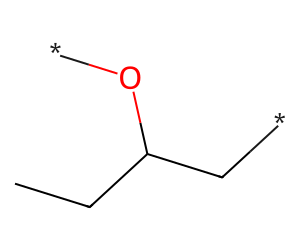

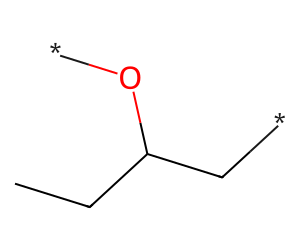

In [16]:
# A
smiles = [
    "CCCCO[*:1]",
    "CC(C[*:2])O[*:3]",
    "CCC(C[*:4])O[*:5]",
    "CCC(C[*:6])O[*:7]"
]
for s in smiles:
    doc = parse(s)
    result = ir_to_gbigsmiles(doc, seed=42)
    atomistic = ir_to_atomistic(doc)
    poly_mol = atomistic_to_rdkit(atomistic)
    display(MolToImage(poly_mol, size=(300, 250)))